# Regresión lineal con `process.csv`

Flujo: carga de datos, limpieza básica, entrenamiento, evaluación y guardado del modelo.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, confusion_matrix, roc_curve
import joblib

RANDOM_STATE = 42
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
start = Path.cwd().resolve()

# Detectar la raíz del proyecto sin recorrer todo el disco
project_root = None
for p in [start, *start.parents]:
    if (p / "pyproject.toml").exists() or (p / "requirements.txt").exists():
        project_root = p
        break
if project_root is None:
    project_root = start

# Nombres posibles del dataset
candidate_names = [
    "procesed.csv",
    "process.csv",
    "data procesed.csv",
    "data_processed.csv",
]

# Buscar rutas candidatas directas
candidate_paths = []
for name in candidate_names:
    candidate_paths.append(project_root / "data" / name)
    candidate_paths.append(project_root / name)
    candidate_paths.append(start / name)

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
    available = []
    for folder in [project_root / "data", project_root, start]:
        if folder.exists():
            available.extend(folder.glob("*.csv"))
    raise FileNotFoundError(
        "No se encontró el CSV esperado. Archivos CSV detectados:\n" +
        "\n".join(str(p) for p in available[:20])
    )

print(f"Archivo encontrado: {csv_path}")
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
display(df.head())
df.info()

Archivo encontrado: C:\Users\venel\Documents\GitHub\IA0526\PRACTICAML\PRACTICA-MACHINE-LEARNING-limpio\data\procesed.csv


Shape: (86634, 26)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_children,week_sin,week_cos
0,Resort Hotel,0,7,2015,July,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,No Deposit,Transient,75.0,0,0,0,-0.120537,-0.992709
1,Resort Hotel,0,13,2015,July,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,No Deposit,Transient,75.0,0,0,0,-0.120537,-0.992709
2,Resort Hotel,0,14,2015,July,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,Transient,98.0,0,1,0,-0.120537,-0.992709
3,Resort Hotel,0,0,2015,July,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,No Deposit,Transient,107.0,0,0,0,-0.120537,-0.992709
4,Resort Hotel,0,9,2015,July,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,No Deposit,Transient,103.0,0,1,0,-0.120537,-0.992709


<class 'pandas.DataFrame'>
RangeIndex: 86634 entries, 0 to 86633
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           86634 non-null  str    
 1   is_canceled                     86634 non-null  int64  
 2   lead_time                       86634 non-null  int64  
 3   arrival_date_year               86634 non-null  int64  
 4   arrival_date_month              86634 non-null  str    
 5   stays_in_weekend_nights         86634 non-null  int64  
 6   stays_in_week_nights            86634 non-null  int64  
 7   adults                          86634 non-null  int64  
 8   children                        86634 non-null  float64
 9   babies                          86634 non-null  int64  
 10  meal                            86634 non-null  str    
 11  country                         86634 non-null  str    
 12  market_segment                  86634 non-n

In [3]:
TARGET = 'is_canceled'
if TARGET not in df.columns:
    raise ValueError(f'No existe la columna objetivo: {TARGET}')

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print('Variable objetivo:', TARGET)
print('Distribucion del target:')
display(y.value_counts(normalize=True).rename('ratio'))
display(df.isna().sum().sort_values(ascending=False).head(10))
print('Duplicados:', df.duplicated().sum())

Variable objetivo: is_canceled
Distribucion del target:


is_canceled
0    0.72318
1    0.27682
Name: ratio, dtype: float64

hotel                      0
is_canceled                0
lead_time                  0
arrival_date_year          0
arrival_date_month         0
stays_in_weekend_nights    0
stays_in_week_nights       0
adults                     0
children                   0
babies                     0
dtype: int64

Duplicados: 2200


In [4]:
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(max_iter=400, class_weight='balanced', random_state=RANDOM_STATE))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

def metrics(y_true, y_pred, y_proba=None, label=''):
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    print(f'[{label}] F1={f1:.4f} | Recall={rec:.4f} | Precision={prec:.4f} | Accuracy={acc:.4f} | ROC-AUC={auc:.4f}')

metrics(y_train, y_pred_train, model.predict_proba(X_train)[:, 1], 'Train')
metrics(y_test, y_pred_test, y_proba_test, 'Test')

[Train] F1=0.6293 | Recall=0.7735 | Precision=0.5304 | Accuracy=0.7477 | ROC-AUC=0.8370
[Test] F1=0.6257 | Recall=0.7711 | Precision=0.5264 | Accuracy=0.7446 | ROC-AUC=0.8347


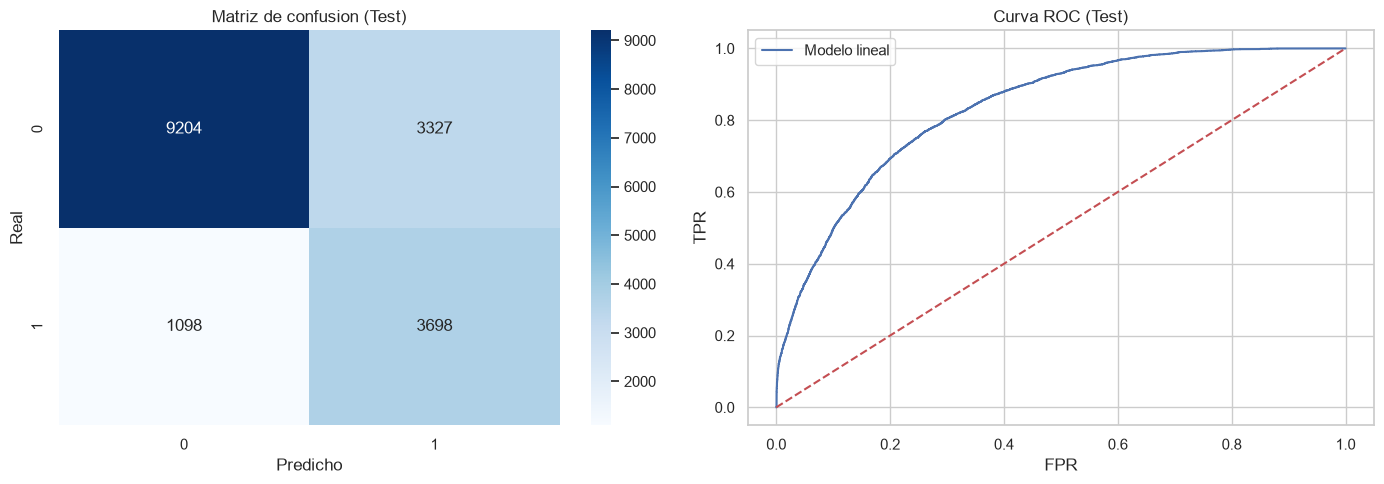

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de confusion (Test)')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

fpr, tpr, _ = roc_curve(y_test, y_proba_test)
axes[1].plot(fpr, tpr, label='Modelo lineal')
axes[1].plot([0, 1], [0, 1], 'r--')
axes[1].set_title('Curva ROC (Test)')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()
coefs = model.named_steps['classifier'].coef_.ravel()
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs, 'abs_coef': np.abs(coefs)}).sort_values('abs_coef', ascending=False)
display(coef_df.head(20))
print('Intercepto:', model.named_steps['classifier'].intercept_[0])

,feature,coef,abs_coef
11,num__required_car_parking_spaces,-3.760693,3.760693
40,cat__country_ARE,2.545647,2.545647
98,cat__country_HKG,1.900019,1.900019
225,cat__deposit_type_Non Refund,1.544835,1.544835
162,cat__country_PRT,1.462390,1.462390
175,cat__country_SRB,-1.432877,1.432877
224,cat__deposit_type_No Deposit,-1.394791,1.394791
154,cat__country_NZL,-1.384235,1.384235
36,cat__country_AGO,1.361828,1.361828
94,cat__country_GIB,1.273837,1.273837


Intercepto: -0.6745458782441047


In [7]:
out_dir = project_root / 'models' / 'test' / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)
model_path = out_dir / 'linear_regression_process.pkl'
joblib.dump(model, model_path)
print(f'Modelo guardado en: {model_path}')

Modelo guardado en: C:\Users\venel\Documents\GitHub\IA0526\PRACTICAML\PRACTICA-MACHINE-LEARNING-limpio\models\test\artifacts\linear_regression_process.pkl


In [8]:
loaded_model = joblib.load(model_path)
sample_proba = loaded_model.predict_proba(X_test.head(5))[:, 1]
sample_pred = loaded_model.predict(X_test.head(5))
display(pd.DataFrame({'real': y_test.head(5).values, 'predicho': sample_pred, 'proba_cancelacion': sample_proba}))

,real,predicho,proba_cancelacion
0,1,1,0.927654
1,0,0,0.412357
2,0,0,0.150583
3,0,0,0.258024
4,1,1,0.715217
